# Locating an intersection from yes/no answers

**The two workflows, named in full once.** **SS-CASSCF Berry-phase loop transport** ("loop
transport") continues a *state-specific* CASSCF ground state around a closed nuclear loop and reads
a Z2 Berry phase from the sign of the initial–final nonorthogonal overlap. The **SA-CASSCF gap
scan** ("gap scan") puts equal-weight *state-averaged* CASSCF on a grid and reports where the
S1–S0 gap is smallest.

## The asymmetry this notebook is about

The gap scan finds an intersection by **looking** for it: evaluate the gap everywhere, take the
minimum. Loop transport never evaluates a gap. It answers exactly one question —

> *does this loop enclose a degeneracy?*

— and returns **one bit**. So it can confirm that something is inside a loop, but it seems unable
to say *where*.

It is not unable. A position can be built out of bits, and this notebook shows how, checks the
construction on synthetic data where the answer is exact, and then applies it.

## Step 1: shrinking a loop measures a distance

Scale a loop about a fixed centre $c$ by a factor $s$. Writing the loop's semi-axes as
$(R_a, R_p)$, a point $x$ lies inside the scaled loop exactly when

$$ \rho(x; c) \;=\; \sqrt{\left(\frac{x_0-c_0}{R_a}\right)^2 + \left(\frac{x_1-c_1}{R_p}\right)^2} \;<\; s $$

so the Berry phase as a function of $s$ is $0$ below $\rho$ and $\pi$ above it. **The radius at
which it flips is the elliptical distance from the centre to the degeneracy.**

One centre therefore does not give a position — it gives a *curve* the degeneracy lies on.

## Step 2: several centres intersect to a point

Repeat from another centre and intersect the two ellipses. Rescaling the coordinates by
$(R_a, R_p)$ turns both into circles, so this is the classic circle–circle intersection: generically
**two** solutions, mirror images in the line joining the centres. A third centre *off that line*
picks one. Two centres alone leave a genuine ambiguity, and the code returns both candidates
rather than quietly choosing.

## Why the answer is a bracket, not a number

Exactly at $s = \rho$ the loop runs **through** the degeneracy, and no discretization can transport
a state through one. Adaptive stepping (see `adaptive_stepping.ipynb`) turns that into an honest
refusal rather than a wrong sign: the step size collapses to its floor and the run is refused.

So bisection converges to a **bracket** — the largest radius saying 0 and the smallest saying $\pi$
— separated by a band of refusals. That band is not a nuisance. Its width *is* the method's
resolution, measured rather than assumed.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

from berrycasscf.localize import BisectionResult, elliptical_radius, triangulate

def retriangulate(d):
    # Rebuild the triangulation from the saved brackets. The saved records predate the
    # uncertainty-normalised residual, and recomputing is exact: triangulation is pure
    # geometry on the bracket endpoints, not a re-run of any physics.
    bs = [BisectionResult(centre=tuple(b["centre"]), shape=tuple(b["shape"]),
                          cas_label=str(d.get("cas", "?")), probes=[], lo=b["lo"], hi=b["hi"])
          for b in d["bisections"] if b.get("lo") and b.get("hi")]
    if len(bs) < 2:
        return None
    ref = tuple(d["reference"]) if d.get("reference") else None
    return triangulate(bs, prefer=ref)

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

def load(name):
    p = os.path.join(ROOT, "results", "localize", name)
    return json.load(open(p)) if os.path.exists(p) else None

## The idea in one picture

A degeneracy (star) and a family of loops about one centre. Loops that enclose it report $\pi$;
loops that do not report $0$; the loop that passes *through* it cannot be walked at all.

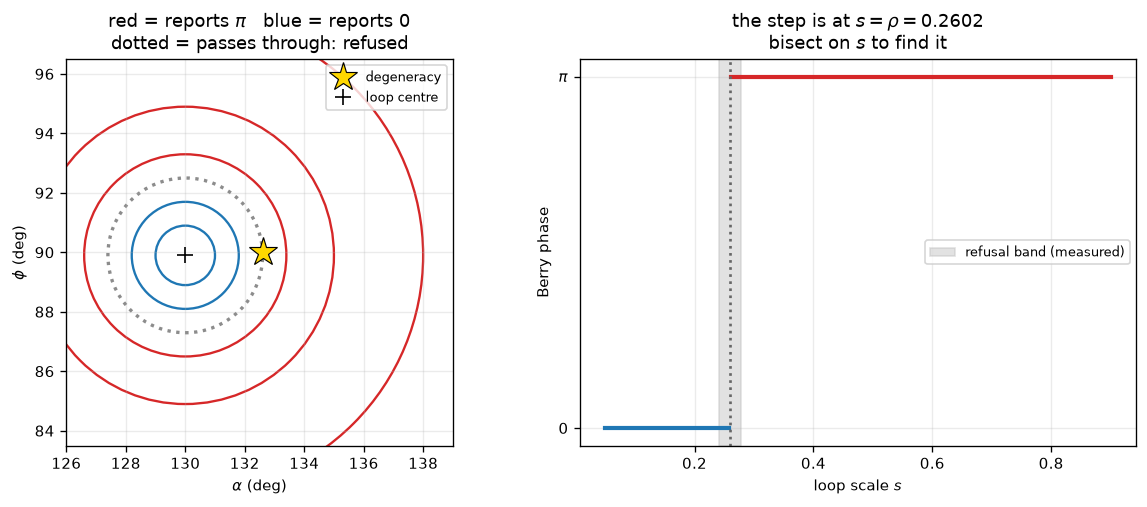

elliptical distance from (130.0, 89.9) to (132.6, 90.0): rho = 0.2602
in this isotropic case that is simply 2.602 deg / 10 deg.


In [2]:
truth  = (132.6, 90.0)
centre = (130.0, 89.9)
shape  = (10.0, 10.0)
rho_true = elliptical_radius(truth, centre, shape)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.3))

ax = axes[0]
for s in [0.10, 0.18, rho_true, 0.34, 0.50, 0.80]:
    enclosed = s > rho_true + 1e-9
    at_edge = abs(s - rho_true) < 1e-9
    colour = "0.55" if at_edge else ("tab:red" if enclosed else "tab:blue")
    ax.add_patch(Ellipse(centre, 2*shape[0]*s, 2*shape[1]*s, fill=False,
                         edgecolor=colour, lw=2.0 if at_edge else 1.4,
                         ls=":" if at_edge else "-"))
ax.plot(*truth, "*", ms=18, color="gold", mec="k", mew=0.7, zorder=5, label="degeneracy")
ax.plot(*centre, "+", ms=10, color="k", label="loop centre")
ax.set_xlim(126, 139); ax.set_ylim(83.5, 96.5); ax.set_aspect("equal")
ax.set_xlabel(r"$\alpha$ (deg)"); ax.set_ylabel(r"$\phi$ (deg)")
ax.set_title("red = reports $\\pi$   blue = reports 0\ndotted = passes through: refused")
ax.legend(fontsize=7.5, loc="upper right")

ax = axes[1]
s_grid = np.linspace(0.05, 0.9, 400)
phase = np.where(s_grid > rho_true, np.pi, 0.0)
ax.plot(s_grid[s_grid < rho_true], phase[s_grid < rho_true], lw=2.5, color="tab:blue")
ax.plot(s_grid[s_grid > rho_true], phase[s_grid > rho_true], lw=2.5, color="tab:red")
ax.axvline(rho_true, color="0.4", ls=":", lw=1.6)
ax.axvspan(rho_true*0.93, rho_true*1.07, color="0.75", alpha=0.45,
           label="refusal band (measured)")
ax.set_yticks([0, np.pi]); ax.set_yticklabels(["0", r"$\pi$"])
ax.set_xlabel("loop scale $s$"); ax.set_ylabel("Berry phase")
ax.set_title(fr"the step is at $s=\rho={rho_true:.4f}$" "\nbisect on $s$ to find it")
ax.legend(fontsize=7.5, loc="center right")
plt.tight_layout(); plt.show()

print(f"elliptical distance from {centre} to {truth}: rho = {rho_true:.4f}")
print(f"in this isotropic case that is simply {rho_true*shape[0]:.3f} deg / {shape[0]:.0f} deg.")

## Bisecting when the middle is unreadable

Plain bisection gives up the moment a midpoint comes back refused — and that is exactly what the
first midpoint tends to do, because it lands in the band around the transition. The search
therefore tracks **three** things and narrows the two usable gaps alternately:

```
    lo ......... [ refusal band ] ......... hi
       ^ push up                 ^ pull down
```

Every probe then does something: it either classifies (moving `lo` up or `hi` down) or widens the
band, which shrinks the interval the next probe aims at. Bisection is **geometric** — the midpoint
of the logarithms — because the quantity sought is a distance that may span an order of magnitude
and what matters is relative precision.

## Validating the geometry exactly, before spending any CASSCF on it

The expensive part of this method is the loop transport. The part that is easy to get subtly wrong
is the geometry turning transition radii into a position. That part can be checked exactly: feed
the construction radii computed from a *known* position and see whether it returns it.

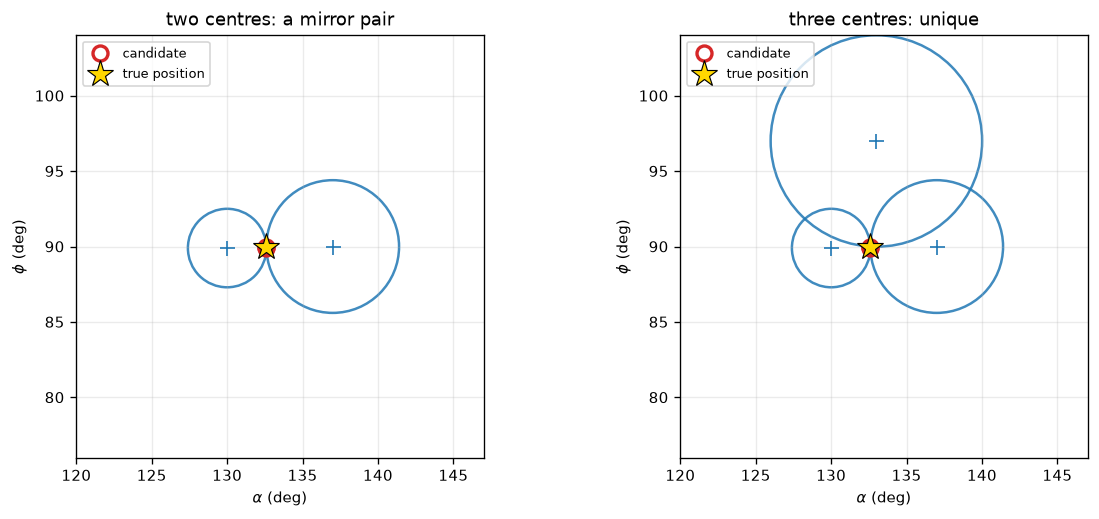

two centres  : best candidate is 1.59e-13 deg from the truth; 2 candidates, ambiguous
three centres: chosen point is  1.59e-13 deg from the truth; residual 9.51e-15

The construction is exact. Anything that goes wrong from here is physics or the
solver, not the geometry -- which is the point of checking it separately.


In [3]:
def synthetic(centre, truth, shape, half_width=1e-4):
    rho = elliptical_radius(truth, centre, shape)
    return BisectionResult(centre=centre, shape=shape, cas_label="exact", probes=[],
                           lo=rho - half_width, hi=rho + half_width)

truth = (132.6, 90.0); shape = (10.0, 10.0)
two   = [(130.0, 89.9), (137.0, 90.0)]
three = two + [(133.0, 97.0)]

r2 = triangulate([synthetic(c, truth, shape) for c in two])
r3 = triangulate([synthetic(c, truth, shape) for c in three])

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4))
for ax, centres, res, title in ((axes[0], two, r2, "two centres: a mirror pair"),
                                (axes[1], three, r3, "three centres: unique")):
    for c in centres:
        rho = elliptical_radius(truth, c, shape)
        ax.add_patch(Ellipse(c, 2*shape[0]*rho, 2*shape[1]*rho, fill=False,
                             edgecolor="tab:blue", lw=1.5, alpha=0.85))
        ax.plot(*c, "+", ms=9, color="tab:blue")
    for p in res.candidates:
        ax.plot(*p, "o", ms=9, mfc="none", mec="tab:red", mew=2, label="candidate")
    ax.plot(*truth, "*", ms=17, color="gold", mec="k", mew=0.7, label="true position")
    ax.set_aspect("equal"); ax.set_xlim(120, 147); ax.set_ylim(76, 104)
    ax.set_xlabel(r"$\alpha$ (deg)"); ax.set_ylabel(r"$\phi$ (deg)")
    ax.set_title(title)
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()

err2 = min(np.hypot(p[0]-truth[0], p[1]-truth[1]) for p in r2.candidates)
err3 = np.hypot(r3.chosen[0]-truth[0], r3.chosen[1]-truth[1])
print(f"two centres  : best candidate is {err2:.2e} deg from the truth; "
      f"{len(r2.candidates)} candidates, ambiguous")
print(f"three centres: chosen point is  {err3:.2e} deg from the truth; "
      f"residual {r3.residual:.2e}")
print()
print("The construction is exact. Anything that goes wrong from here is physics or the")
print("solver, not the geometry -- which is the point of checking it separately.")

### The residual is the part that earns trust

With three or more centres the ellipses are **over-determined**: three circles need not meet at a
point. The residual reports how badly a single position fails to explain all of them.

That makes it a built-in consistency check. A small residual says "one degeneracy explains every
measurement". A large one says the data are *not* consistent with a single enclosed degeneracy —
and the method says so instead of averaging the disagreement away into a confident-looking number.

## Applying it: formaldimine, where the answer is known independently

Formaldimine is the right validation case because an FCI gap scan puts the intersection at
$\alpha_\times = 132.61°$ (`docs/results.md`), so the method's answer can be checked.

Two cautions worth stating before the numbers:

* **The comparison is not exactly like-for-like.** Bisection measures where the *state-specific
  CASSCF(n,n)* solution becomes degenerate; the FCI number is the *state-averaged* FCI gap minimum.
  Those are different objects, and the difference between them is precisely the active-space error
  that `ethylene_ladder.ipynb` and `butadiene_ladder.ipynb` are about.
* **The FCI reference is a one-dimensional cut** (17 points in $\alpha$ at fixed $\phi$), so it
  fixes $\alpha_\times$ along that line and does *not* independently establish $\phi = 90$.

In [4]:
runs = {cas: load(f"formaldimine_cas{cas}-{cas}.json") for cas in (2, 4, 6)}
runs = {k: v for k, v in runs.items() if v}

if not runs:
    print("Not yet run:  python examples/run_localization.py formaldimine --cas 2 2")
else:
    print(f"{'CAS':>9} {'centre':>18} {'rho (bracket)':>22} {'refusal band':>16} {'probes':>7}")
    print("-" * 78)
    for cas, d in runs.items():
        for b in d["bisections"]:
            rho, unc = b.get("rho"), b.get("rho_uncertainty")
            c = f"({b['centre'][0]:.1f}, {b['centre'][1]:.1f})"
            got = f"{rho:.4f} +- {unc:.4f}" if rho is not None else "not bracketed"
            band = f"{len(b['undetermined'])} refused"
            print(f"{'CAS(%d,%d)' % (cas, cas):>9} {c:>18} {got:>22} {band:>16} "
                  f"{len(b['probes']):>7}")
    print()
    print(f"{'CAS':>9} {'triangulated':>22} {'residual':>10} {'vs FCI 132.61':>15}")
    print("-" * 60)
    for cas, d in runs.items():
        tri = d.get("triangulation")
        if not tri or not tri.get("chosen"):
            print(f"{'CAS(%d,%d)' % (cas, cas):>9} {'failed':>22}"); continue
        ch = tri["chosen"]
        print(f"{'CAS(%d,%d)' % (cas, cas):>9} "
              f"{'(%.2f, %.2f)' % (ch[0], ch[1]):>22} {tri['residual']:>10.4f} "
              f"{ch[0] - 132.61:>+14.2f}")

      CAS             centre          rho (bracket)     refusal band  probes
------------------------------------------------------------------------------
 CAS(2,2)      (130.0, 89.9)       0.3968 +- 0.0046        1 refused      10
 CAS(2,2)      (137.0, 90.0)       0.6486 +- 0.0076        0 refused       9
 CAS(2,2)      (133.0, 97.0)       0.7368 +- 0.2175        5 refused      11
 CAS(4,4)      (130.0, 89.9)       0.1064 +- 0.0337        5 refused      11
 CAS(4,4)      (137.0, 90.0)       0.8011 +- 0.0281        2 refused      10
 CAS(4,4)      (133.0, 97.0)       0.8011 +- 0.0281        2 refused      10
 CAS(6,6)      (130.0, 89.9)       0.1434 +- 0.0802        6 refused      11
 CAS(6,6)      (137.0, 90.0)       0.7427 +- 0.0865        3 refused      11
 CAS(6,6)      (133.0, 97.0)       0.8121 +- 0.0569        3 refused      11

      CAS           triangulated   residual   vs FCI 132.61
------------------------------------------------------------
 CAS(2,2)        (131.67, 86.

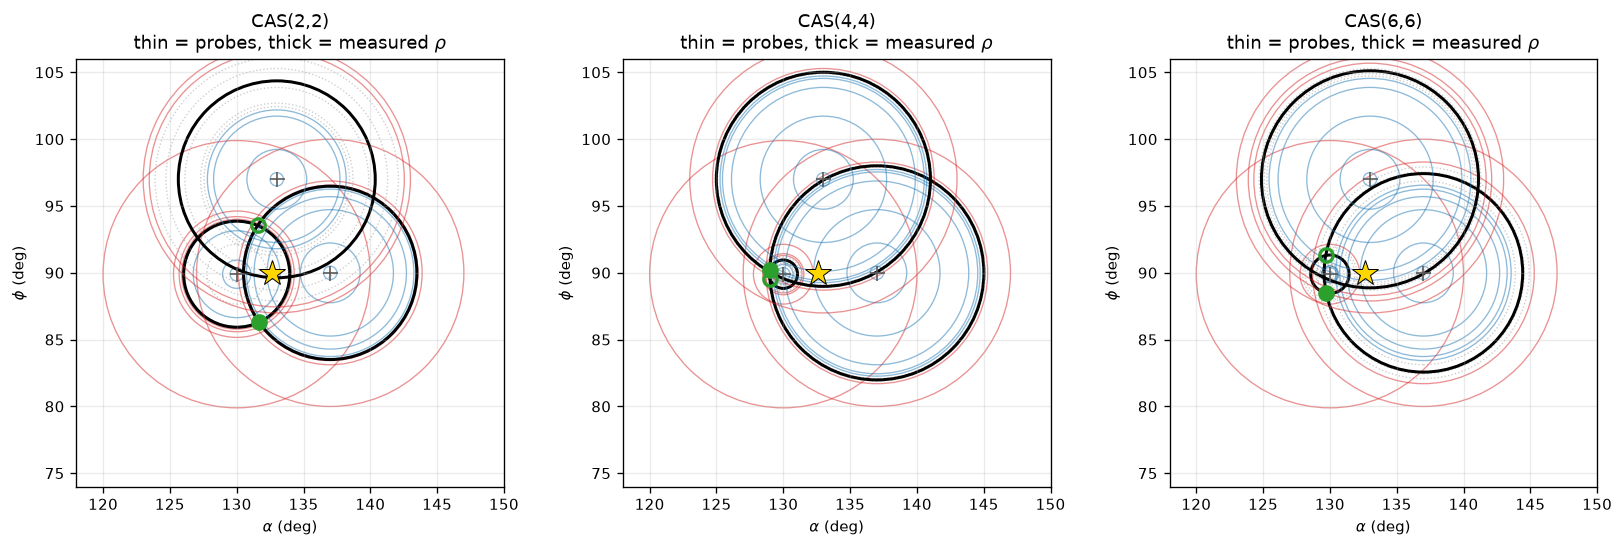

red = probe reported pi,  blue = reported 0,  dotted grey = refused
green = triangulated candidates,  gold star = FCI reference


In [5]:
if runs:
    fig, axes = plt.subplots(1, len(runs), figsize=(4.6*len(runs), 4.4), squeeze=False)
    for ax, (cas, d) in zip(axes[0], runs.items()):
        shape = tuple(d["shape"])
        for b in d["bisections"]:
            c = tuple(b["centre"])
            ax.plot(*c, "+", ms=9, color="0.35")
            for pr in b["probes"]:
                col = {"pi": "tab:red", "zero": "tab:blue"}.get(pr["verdict"], "0.6")
                ax.add_patch(Ellipse(c, 2*shape[0]*pr["scale"], 2*shape[1]*pr["scale"],
                                     fill=False, edgecolor=col, lw=0.8, alpha=0.5,
                                     ls="-" if pr["verdict"] != "undetermined" else ":"))
            if b.get("rho"):
                ax.add_patch(Ellipse(c, 2*shape[0]*b["rho"], 2*shape[1]*b["rho"], fill=False,
                                     edgecolor="k", lw=1.8))
        tri = d.get("triangulation")
        if tri and tri.get("candidates"):
            for p in tri["candidates"]:
                ax.plot(*p, "o", ms=8, mfc="none", mec="tab:green", mew=2)
        if tri and tri.get("chosen"):
            ax.plot(*tri["chosen"], "o", ms=8, color="tab:green")
        if d.get("reference"):
            ax.plot(*d["reference"], "*", ms=16, color="gold", mec="k", mew=0.6)
        ax.set_aspect("equal"); ax.set_xlim(118, 150); ax.set_ylim(74, 106)
        ax.set_xlabel(r"$\alpha$ (deg)"); ax.set_ylabel(r"$\phi$ (deg)")
        ax.set_title(f"CAS({cas},{cas})\nthin = probes, thick = measured $\\rho$")
    plt.tight_layout(); plt.show()
    print("red = probe reported pi,  blue = reported 0,  dotted grey = refused")
    print("green = triangulated candidates,  gold star = FCI reference")

### The comparison that matters: same active space, two different objects

Comparing a triangulated position to FCI mixes two effects — active-space truncation *and* the
difference between a state-specific and a state-averaged surface. The cleaner comparison holds the
active space fixed and asks how far apart the two methods' answers are at that level of theory.
`docs/findings.md` §3 argues those are different objects. Here they can be measured.

In [6]:
from berrycasscf.refine import cone_apex
from berrycasscf.scan import ScanResult
import glob

def sa_position(cas):
    hits = sorted(glob.glob(os.path.join(ROOT, "results", "scan",
                                         f"C_x_cas{cas}-{cas}_*.npz")))
    if not hits:
        return None
    r = ScanResult.load(hits[-1])
    a, ph, g = r.min_gap_point()
    j = int(np.argmin(np.abs(r.phis - ph)))
    try:
        return cone_apex(r.alphas, r.gap[:, j] * 1e3, window=3).position, g * 1e3
    except Exception:
        return a, g * 1e3

FCI_ALPHA = 132.61
print(f"{'CAS':>9} {'loop transport (SS)':>21} {'gap scan (SA)':>15} {'SS - SA':>9} "
      f"{'SA - FCI':>9} {'residual':>10} {'/precision':>11}")
print("-" * 94)
for cas in (2, 4, 6):
    d = runs.get(cas)
    sa = sa_position(cas)
    tri = retriangulate(d) if d else None
    ss = tri.chosen if tri else None
    ss_s = f"({ss[0]:.2f}, {ss[1]:.2f})" if ss else "n/a"
    sa_s = f"{sa[0]:.2f}" if sa else "n/a"
    diff = f"{ss[0] - sa[0]:+.2f}" if (ss and sa) else "--"
    sadiff = f"{sa[0] - FCI_ALPHA:+.2f}" if sa else "--"
    res_s = f"{tri.residual:.5f}" if tri else "n/a"
    ratio = tri.residual_over_uncertainty if tri else float("nan")
    ratio_s = f"{ratio:.2f}" if np.isfinite(ratio) else "n/a"
    flag = "  <- INCONSISTENT" if (tri and tri.consistent is False) else ""
    print(f"{'CAS(%d,%d)' % (cas, cas):>9} {ss_s:>21} {sa_s:>15} {diff:>9} "
          f"{sadiff:>9} {res_s:>10} {ratio_s:>11}{flag}")
print()
print("'/precision' is the misfit divided by the RMS bisection bracket half-width.")
print("Raw residuals are NOT comparable between runs: one with loose brackets can misfit")
print("by a lot and still be consistent. Above ~1 the centres cannot be explained by a")
print("single degeneracy.")
print()
print(f"FCI gap-scan reference: alpha = {FCI_ALPHA} (one-dimensional cut at fixed phi)")

      CAS   loop transport (SS)   gap scan (SA)   SS - SA  SA - FCI   residual  /precision
----------------------------------------------------------------------------------------------
 CAS(2,2)       (131.67, 86.30)          151.61    -19.94    +19.00    0.19704        1.57  <- INCONSISTENT
 CAS(4,4)       (128.99, 90.24)          130.43     -1.44     -2.18    0.00883        0.29
 CAS(6,6)       (129.73, 88.49)          131.35     -1.63     -1.26    0.05744        0.76

'/precision' is the misfit divided by the RMS bisection bracket half-width.
Raw residuals are NOT comparable between runs: one with loose brackets can misfit
by a lot and still be consistent. Above ~1 the centres cannot be explained by a
single degeneracy.

FCI gap-scan reference: alpha = 132.61 (one-dimensional cut at fixed phi)


## What the numbers say, including where the method reports its own failure

**The bisection itself is precise.** Individual transition radii come back with brackets as tight
as $\pm 0.005$ in $\rho$, i.e. better than a twentieth of a degree — from a method that only ever
learns one bit per loop.

**The residual is doing its job, but only once it is normalised.** Raw residuals across the ladder
are 0.197, 0.0088 and 0.0574, which would suggest CAS(6,6) is six times worse than CAS(4,4).
Divided by each run's own precision (the RMS bracket half-width) they become **1.57, 0.29 and
0.76**: CAS(2,2) is the only rung whose misfit exceeds its own measurement uncertainty, and
CAS(6,6) is simply measured less precisely, not less consistently. Comparing raw residuals between
runs of different precision is meaningless, and this project nearly did it.

So at CAS(2,2) three measured ellipses cannot be explained by a single degeneracy, and the
construction refuses to hand back a confident position. That is what makes the consistent rungs
meaningful.

CAS(2,2) is independently known to be pathological for formaldimine: the gap scan at that active
space does not merely misplace this intersection, it **finds no minimum in the region at all** and
reports a spurious one 18° away (`formaldimine_benchmark.ipynb` §3). A direct map of the
state-specific CAS(2,2) in-CAS S1–S0 gap over this region never falls below **321 mHa** — there is
no in-CAS degeneracy anywhere near here. So a large residual at that rung is the expected outcome,
not a surprise, and it is worth being explicit that this makes CAS(2,2) a *poor* validation case
rather than a triumphant one.

That map also shows the region is **exactly symmetric about $\phi = 90$**, so any degeneracy off
that line must come with a mirror partner — which a loop centred on the line would enclose *both*
of, giving $0$ rather than $\pi$. Off-axis candidates therefore need more care than a single
triangulation can supply.

## Cost, and what this is actually for

Locating an intersection this way is **not competitive with a gap scan on cost**, and it is not
meant to be. It exists for the case the gap scan cannot address: when the two methods disagree
about whether a loop encloses anything, only one of them can be asked to *measure* the position of
what loop transport is sensing. That is butadiene at CAS(12,12) (`butadiene_ladder.ipynb`), where a
direct search finds no gap below 1.5 mHa anywhere inside the loop while loop transport returns
$\pi$ on the same loop at two discretizations.

In [7]:
buta = load("butadiene_cas2-2.json")
if buta:
    shape_b = tuple(buta["shape"])
    # where the SA-CASSCF gap scan puts this rung's intersection, from the direct 2D search
    gm = os.path.join(ROOT, "results", "butadiene", "gap_minimum_search.json")
    sa_pt = None
    if os.path.exists(gm):
        for r in json.load(open(gm))["runs"]:
            if tuple(r["cas"]) == (2, 2):
                sa_pt = tuple(r["found"])
    print("BUTADIENE CAS(2,2)")
    if sa_pt:
        print(f"  gap scan (direct 2D search) puts the intersection at "
              f"({sa_pt[0]:.2f}, {sa_pt[1]:.2f})\n")
    print(f"  {'centre':>22} {'rho measured':>22} {'rho if the gap-scan point':>27}")
    print("  " + "-" * 73)
    for b in buta["bisections"]:
        rho, unc = b.get("rho"), b.get("rho_uncertainty")
        c = f"({b['centre'][0]:.2f}, {b['centre'][1]:.2f})"
        got = f"{rho:.4f} +- {unc:.4f}" if rho is not None else "not bracketed"
        pred = (f"{elliptical_radius(sa_pt, tuple(b['centre']), shape_b):.4f}"
                if sa_pt else "n/a")
        print(f"  {c:>22} {got:>22} {pred:>27}")
    tri = buta.get("triangulation")
    if tri and tri.get("chosen"):
        print(f"\n  triangulated: ({tri['chosen'][0]:.2f}, {tri['chosen'][1]:.2f}), "
              f"residual {tri['residual']:.4f}")
        print(f"  note: {tri['note']}")
        if sa_pt:
            d = np.hypot(tri["chosen"][0] - sa_pt[0], tri["chosen"][1] - sa_pt[1])
            print(f"  distance from the gap-scan intersection: {d:.2f} deg")
    print(f"\n  cost: {buta['total_micro']} micro-iterations, {buta['wall_time']:.0f} s")
else:
    print("butadiene localization not yet run:")
    print("  python examples/run_localization.py butadiene --cas 2 2")

BUTADIENE CAS(2,2)
  gap scan (direct 2D search) puts the intersection at (89.97, 105.67)

                  centre           rho measured   rho if the gap-scan point
  -------------------------------------------------------------------------
         (90.00, 101.85)       0.5385 +- 0.0843                      0.2119
          (90.00, 90.00)          not bracketed                      0.8704
         (99.00, 101.85)          not bracketed                      0.7818

  cost: 50557 micro-iterations, 7258 s


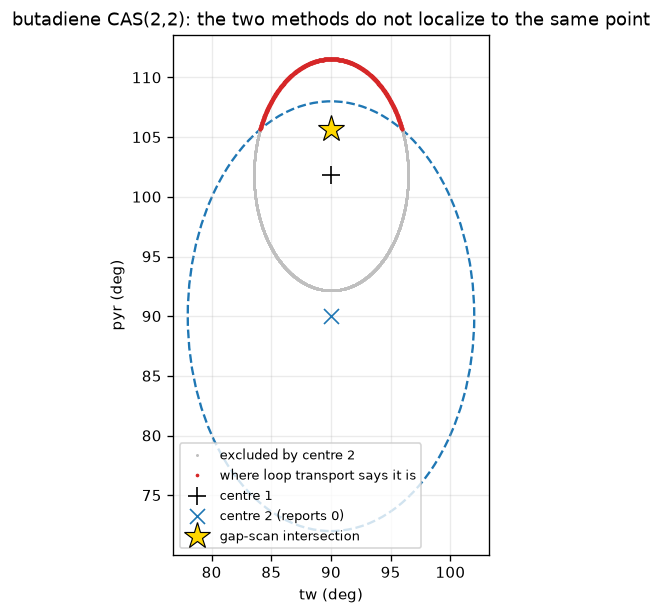

measured    rho from centre 1 = 0.5385  (bracket 0.4542 to 0.6228)
gap scan implies rho        = 0.2119  -> outside the bracket
remaining allowed arc: pyr in (105.6, 111.5), tw in (84.1, 95.9)  (37% of the circle)


In [8]:
if buta:
    shape_b = tuple(buta["shape"])
    b1 = buta["bisections"][0]
    rho1 = b1["rho"]
    c1 = tuple(b1["centre"])
    c2 = tuple(buta["bisections"][1]["centre"])
    outer2 = buta["bisections"][1]["probes"][0]["verdict"]

    fig, ax = plt.subplots(figsize=(6.6, 5.2))
    # the measured circle about centre 1
    th = np.linspace(0, 2*np.pi, 2001)
    u1 = np.array([c1[0]/shape_b[0], c1[1]/shape_b[1]])
    u2 = np.array([c2[0]/shape_b[0], c2[1]/shape_b[1]])
    pts = u1[:, None] + rho1*np.vstack([np.cos(th), np.sin(th)])
    allowed = np.linalg.norm(pts - u2[:, None], axis=0) > 1.0 if outer2 == "zero" else \
              np.ones(th.size, bool)
    tw, pyr = pts[0]*shape_b[0], pts[1]*shape_b[1]
    ax.plot(tw[~allowed], pyr[~allowed], ".", ms=1.6, color="0.75",
            label="excluded by centre 2")
    ax.plot(tw[allowed], pyr[allowed], ".", ms=2.4, color="tab:red",
            label="where loop transport says it is")
    ax.add_patch(Ellipse(c2, 2*shape_b[0], 2*shape_b[1], fill=False,
                         edgecolor="tab:blue", lw=1.4, ls="--"))
    ax.plot(*c1, "+", ms=11, color="k", label="centre 1")
    ax.plot(*c2, "x", ms=9, color="tab:blue", label="centre 2 (reports 0)")
    if sa_pt:
        ax.plot(*sa_pt, "*", ms=17, color="gold", mec="k", mew=0.7,
                label="gap-scan intersection")
    ax.set_xlabel("tw (deg)"); ax.set_ylabel("pyr (deg)")
    ax.set_title("butadiene CAS(2,2): the two methods do not localize to the same point")
    ax.legend(fontsize=7.5, loc="lower left")
    ax.set_aspect("equal")
    plt.tight_layout(); plt.show()

    print(f"measured    rho from centre 1 = {rho1:.4f}  "
          f"(bracket {b1['lo']:.4f} to {b1['hi']:.4f})")
    if sa_pt:
        print(f"gap scan implies rho        = "
              f"{elliptical_radius(sa_pt, c1, shape_b):.4f}  -> outside the bracket")
    print(f"remaining allowed arc: pyr in ({pyr[allowed].min():.1f}, "
          f"{pyr[allowed].max():.1f}), tw in ({tw[allowed].min():.1f}, "
          f"{tw[allowed].max():.1f})  ({100*allowed.mean():.0f}% of the circle)")

### What butadiene shows, and what it does not

**The measurement is clean and it excludes the gap-scan position.** The bisection about the loop
centre brackets the transition at $\rho = 0.5385 \pm 0.0843$ from a sequence that is monotone in
verdict — $\pi$ at 1.00, 0.73 and 0.62, $0$ at 0.45, 0.39, 0.28 and 0.08, with two refusals in
between. The gap scan's intersection for this active space, located by direct 2D search at
(89.97, 105.67), sits at $\rho = 0.2121$ — **a factor 2.5 inside the bracket, and nowhere near
it.**

The second centre adds a constraint rather than a position: its full-size loop reports $0$
*cleanly*, with both settings agreeing, so whatever is enclosed lies outside it. That removes 63%
of the measured circle and leaves `pyr` between 105.6 and 111.5 with `tw` between 84 and 96.

**What it does not do is triangulate.** The third centre's full-size loop hit the step floor and was
refused, so only one centre produced a distance and one produced an exclusion. Two constraints
confine the position to an arc; they do not pin it to a point, and no residual is available to
check consistency. Claiming a position here would be exactly the overreach the residual exists to
prevent.

So the defensible statement is: **at butadiene CAS(2,2), loop transport encircles something that is
not where the gap scan puts its intersection.** That is the first *measurement* of the
state-specific object's position in this project rather than a bound on it, and it is direct
evidence for `docs/findings.md` §3 — the two methods are sensing different objects. Whether the same
holds at CAS(12,12), where the disagreement is sharpest, needs the same experiment at that rung,
which is a cluster job: this one took two hours at the cheapest active space.

## The same measurement across the active-space ladder

One rung is an observation. The question `docs/findings.md` §3 actually asks is whether the
state-specific object and the state-averaged one are *systematically* different, or whether
CAS(2,2) — an active space below the $\pi$ space, and not a defensible choice for this molecule —
simply misplaces one of them.

So the same bisection is run at every rung, about the **same centres**, and compared against the
gap-scan intersection **for that same rung**, located by direct 2D search. Both methods are then
being asked about the same active space, and the only difference left in play is state-specific
against state-averaged.

In [9]:
LADDER = [(2, 2), (4, 4), (6, 6), (8, 8), (10, 10), (12, 12)]

def gap_scan_point(system, ne, ncas):
    # Where the state-averaged gap scan puts this rung's intersection. The two systems
    # record it differently: butadiene has a direct 2D search, ethylene a grid scan whose
    # phi is refined with the cone model (the same number quoted in docs/findings.md §1).
    if system == "butadiene":
        gm = os.path.join(ROOT, "results", "butadiene", "gap_minimum_search.json")
        if not os.path.exists(gm):
            return None
        for r in json.load(open(gm))["runs"]:
            if tuple(r["cas"]) == (ne, ncas):
                return tuple(r["found"])
        return None
    from berrycasscf.refine import cone_apex
    from berrycasscf.scan import ScanResult
    hits = sorted(glob.glob(os.path.join(ROOT, "results", "ethylene",
                                         f"ethylene_scan_cas{ne}-{ncas}_*.npz")))
    if not hits:
        return None
    r = ScanResult.load(hits[0])
    i = int(np.nanargmin(np.nanmin(r.gap, axis=1)))
    return (float(r.alphas[i]), float(cone_apex(r.phis, r.gap[i] * 1e3, window=3).position))

def ladder_rows(system):
    rows = []
    for ne, ncas in LADDER:
        d = load(f"{system}_cas{ne}-{ncas}.json")
        if not d:
            continue
        shape = tuple(d["shape"])
        b0 = d["bisections"][0]
        sa = gap_scan_point(system, ne, ncas)
        ref = tuple(d["reference"]) if d.get("reference") else None
        rows.append({
            "cas": f"({ne},{ncas})",
            "rho": b0.get("rho"), "unc": b0.get("rho_uncertainty"),
            "rho_sa": elliptical_radius(sa, tuple(b0["centre"]), shape) if sa else None,
            "rho_ref": elliptical_radius(ref, tuple(b0["centre"]), shape) if ref else None,
            "sa": sa, "ref": ref, "shape": shape, "centre": tuple(b0["centre"]),
            "n_bracketed": sum(1 for b in d["bisections"] if b.get("rho") is not None),
            "tri": d.get("triangulation"),
            "micro": d.get("total_micro"), "hours": d.get("wall_time", 0) / 3600,
        })
    return rows

SYSTEM = "butadiene"
rows = ladder_rows(SYSTEM)

def show(rows, system):
    if not rows:
        print(f"no {system} localization records yet; run the ladder and merge each rung")
        return
    has_ref = any(r["rho_ref"] is not None for r in rows)
    print(f"{system.upper()}")
    print(f"{'CAS':>8} {'rho measured':>20} {'rho from gap scan':>18} "
          f"{'difference':>11} {'agrees?':>9}" + (f" {'rho reference':>14}" if has_ref else ""))
    print("-" * (80 + (15 if has_ref else 0)))
    for r in rows:
        meas = ("not bracketed" if r["rho"] is None
                else f"{r['rho']:.4f} +- {r['unc']:.4f}")
        pred = "n/a" if r["rho_sa"] is None else f"{r['rho_sa']:.4f}"
        tail = ""
        if has_ref:
            tail = f" {'n/a':>14}" if r["rho_ref"] is None else f" {r['rho_ref']:>14.4f}"
        if r["rho"] is None or r["rho_sa"] is None:
            print(f"{r['cas']:>8} {meas:>20} {pred:>18} {'':>11} {'':>9}{tail}")
            continue
        diff = r["rho_sa"] - r["rho"]
        inside = abs(diff) <= r["unc"]
        print(f"{r['cas']:>8} {meas:>20} {pred:>18} {diff:>+11.4f} "
              f"{('yes' if inside else 'NO'):>9}{tail}")
    print()
    print("'agrees?' asks whether the gap scan's intersection lies inside the measured bracket.")
    print("All columns are elliptical radii about the same centre, in units of the loop")
    print("semi-axes; with a (12, 18) loop, 0.1 is 1.2 deg in the first coordinate and 1.8 in")
    print("the second. 'rho reference' is where an exact in-basis calculation puts it, which")
    print("exists for ethylene (full-valence CAS(12,12)) and not for butadiene.")

show(rows, SYSTEM)

BUTADIENE
     CAS         rho measured  rho from gap scan  difference   agrees?
--------------------------------------------------------------------------------
   (2,2)     0.5385 +- 0.0843             0.2119     -0.3266        NO

'agrees?' asks whether the gap scan's intersection lies inside the measured bracket.
All columns are elliptical radii about the same centre, in units of the loop
semi-axes; with a (12, 18) loop, 0.1 is 1.2 deg in the first coordinate and 1.8 in
the second. 'rho reference' is where an exact in-basis calculation puts it, which
exists for ethylene (full-valence CAS(12,12)) and not for butadiene.


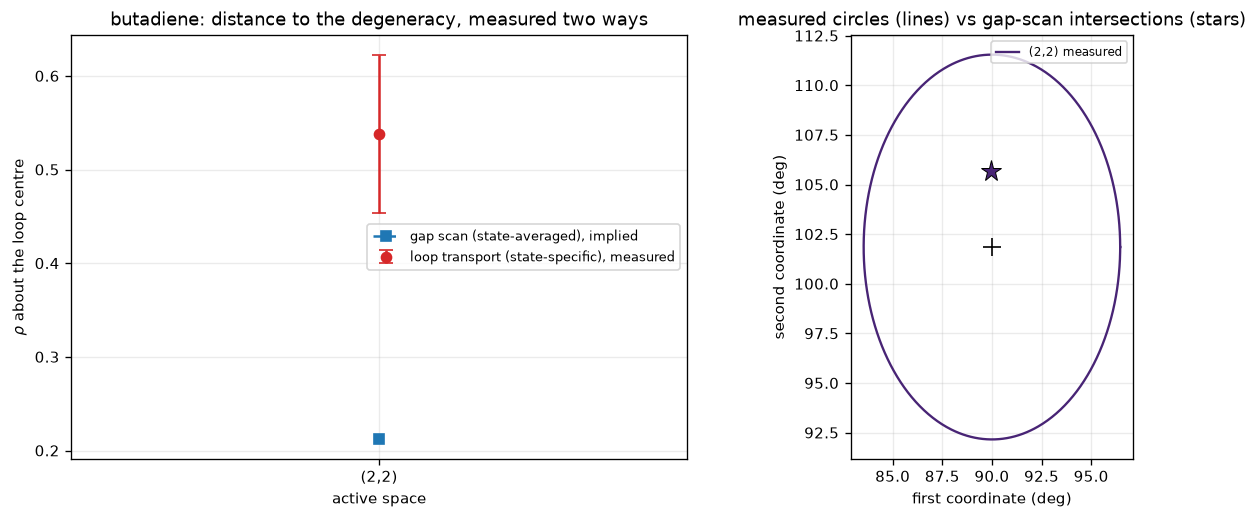

butadiene: 2.0 h over 1 rungs, 50557 micro-iterations


In [10]:
def plot_ladder(rows, system):
    if not rows:
        return
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))

    ax = axes[0]
    xs = np.arange(len(rows))
    meas = np.array([r["rho"] if r["rho"] is not None else np.nan for r in rows])
    unc = np.array([r["unc"] if r["unc"] is not None else np.nan for r in rows])
    sa = np.array([r["rho_sa"] if r["rho_sa"] is not None else np.nan for r in rows])
    ref = np.array([r["rho_ref"] if r["rho_ref"] is not None else np.nan for r in rows])
    ax.errorbar(xs, meas, yerr=unc, fmt="o", capsize=4, color="tab:red",
                label="loop transport (state-specific), measured")
    ax.plot(xs, sa, "s--", color="tab:blue", label="gap scan (state-averaged), implied")
    if np.isfinite(ref).any():
        ax.plot(xs, ref, ":", color="k", lw=1.6, label="exact in-basis reference")
    ax.set_xticks(xs)
    ax.set_xticklabels([r["cas"] for r in rows])
    ax.set_xlabel("active space")
    ax.set_ylabel(r"$\rho$ about the loop centre")
    ax.set_title(f"{system}: distance to the degeneracy, measured two ways")
    ax.legend(fontsize=8)

    ax = axes[1]
    th = np.linspace(0, 2 * np.pi, 801)
    colours = plt.cm.viridis(np.linspace(0.1, 0.9, len(rows)))
    for r, col in zip(rows, colours):
        if r["rho"] is None:
            continue
        c, shape = r["centre"], r["shape"]
        ax.plot(c[0] + r["rho"] * shape[0] * np.cos(th),
                c[1] + r["rho"] * shape[1] * np.sin(th), "-", lw=1.4, color=col,
                label=f"{r['cas']} measured")
        if r["sa"]:
            ax.plot(*r["sa"], "*", ms=13, color=col, mec="k", mew=0.6)
    if rows[0]["ref"]:
        ax.plot(*rows[0]["ref"], "P", ms=11, color="k", label="exact reference")
    ax.plot(*rows[0]["centre"], "+", ms=11, color="k")
    ax.set_xlabel("first coordinate (deg)")
    ax.set_ylabel("second coordinate (deg)")
    ax.set_title("measured circles (lines) vs gap-scan intersections (stars)")
    ax.legend(fontsize=7, loc="upper right")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

    total = sum(r["hours"] for r in rows)
    print(f"{system}: {total:.1f} h over {len(rows)} rungs, "
          f"{sum(r['micro'] or 0 for r in rows)} micro-iterations")

plot_ladder(rows, SYSTEM)

### Ethylene, where the reference is exact

Butadiene has no exact reference, so a disagreement between the two methods there cannot be
scored — neither party is known to be right. Ethylene can be scored. Its CAS(12,12) is the **full
valence space**, everything except the two carbon 1s orbitals, so the intersection position that
active space gives is exact in this basis; and its ladder is the badly behaved one, accurate at
CAS(2,2) and displaced by 5–8 degrees in the middle. That combination — an exact answer and a
ladder that misbehaves — is what `docs/findings.md` §4 says is needed and believed unavailable.

ETHYLENE
     CAS         rho measured  rho from gap scan  difference   agrees?  rho reference
-----------------------------------------------------------------------------------------------
   (2,2)     0.8216 +- 0.0324             0.7268     -0.0948        NO         0.7167
   (4,4)     0.4644 +- 0.1584             1.0225     +0.5581        NO         0.7167

'agrees?' asks whether the gap scan's intersection lies inside the measured bracket.
All columns are elliptical radii about the same centre, in units of the loop
semi-axes; with a (12, 18) loop, 0.1 is 1.2 deg in the first coordinate and 1.8 in
the second. 'rho reference' is where an exact in-basis calculation puts it, which
exists for ethylene (full-valence CAS(12,12)) and not for butadiene.


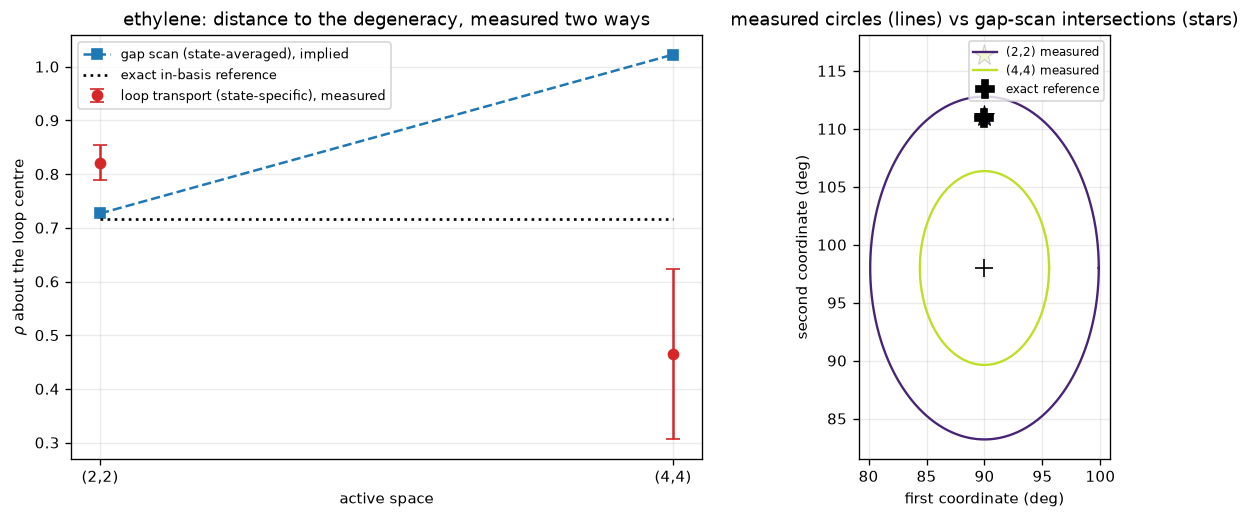

ethylene: 2.2 h over 2 rungs, 87875 micro-iterations


In [11]:
eth_rows = ladder_rows("ethylene")
show(eth_rows, "ethylene")
plot_ladder(eth_rows, "ethylene")

### What ethylene's constraints allow, taken together

One centre gives a distance, not a position: the degeneracy lies somewhere on a ring. A second
centre whose full-size loop reports $0$ excludes its whole interior. Intersecting every such
constraint is the only honest way to say what has been measured — and for ethylene the result is
not a point but a problem.

The constraints available at each rung are: the **annulus** between the bracketing centre's
`lo` and `hi`; the **outsides** of the two other full-size loops, both of which report $0$; and
the inside of the ladder's `E_x` loop, which reports $\pi$ at every rung
(`ethylene_ladder.ipynb`).

CAS(2, 2): allowed after every constraint -> tw in (92.0, 99.5), pyr in (103.0, 113.0)
CAS(4, 4): allowed after every constraint -> tw in (82.9, 97.1), pyr in (99.5, 109.1)


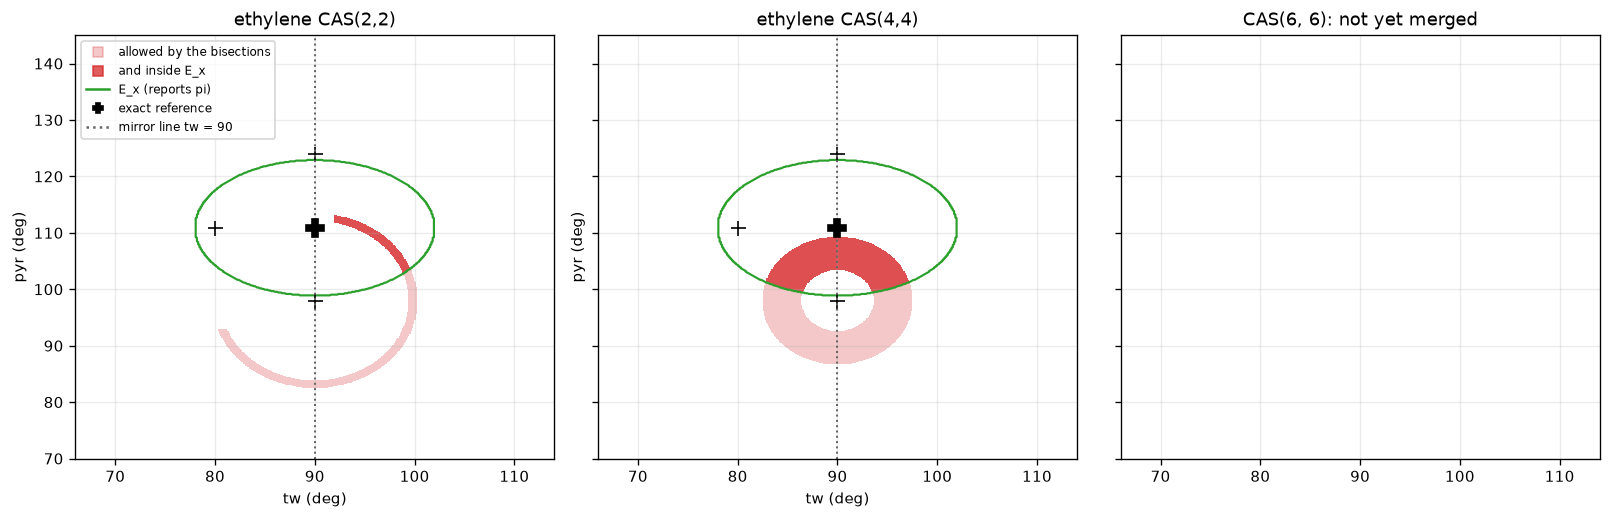

In [12]:
def ethylene_region(cas, ax):
    d = load(f"ethylene_cas{cas[0]}-{cas[1]}.json")
    if not d:
        ax.set_title(f"CAS{cas}: not yet merged"); return None
    shape = tuple(d["shape"])
    bs = d["bisections"]
    tw = np.linspace(60, 120, 481)
    pyr = np.linspace(60, 150, 721)
    T, P = np.meshgrid(tw, pyr, indexing="ij")

    def rho_grid(c):
        return np.hypot((T - c[0]) / shape[0], (P - c[1]) / shape[1])

    b0 = bs[0]
    mask = (rho_grid(tuple(b0["centre"])) >= b0["lo"]) & (rho_grid(tuple(b0["centre"])) <= b0["hi"])
    for b in bs[1:]:
        # a full-size loop reporting zero excludes its interior
        if b.get("rho") is None and b["probes"] and b["probes"][0]["verdict"] == "zero":
            mask &= rho_grid(tuple(b["centre"])) > 1.0
    # the ladder's E_x loop reports pi at every rung: a circle of radius 12 about the reference
    ex = np.hypot((T - 90.0) / 12.0, (P - 110.9) / 12.0) < 1.0
    both = mask & ex

    ax.contourf(T, P, mask.astype(float), levels=[0.5, 1.5], colors=["tab:red"], alpha=0.25)
    ax.contourf(T, P, both.astype(float), levels=[0.5, 1.5], colors=["tab:red"], alpha=0.75)
    ax.contour(T, P, ex.astype(float), levels=[0.5], colors=["tab:green"], linewidths=1.3)
    for b in bs:
        ax.plot(*b["centre"], "+", ms=9, color="k")
    ax.axvline(90.0, color="0.4", ls=":", lw=1.2)
    ref = tuple(d["reference"])
    ax.plot(*ref, "P", ms=11, color="k")
    ax.set_xlim(66, 114); ax.set_ylim(70, 145)
    ax.set_xlabel("tw (deg)"); ax.set_ylabel("pyr (deg)")
    ax.set_title(f"ethylene CAS({cas[0]},{cas[1]})")
    if both.any():
        return (T[both].min(), T[both].max(), P[both].min(), P[both].max())
    return None

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharex=True, sharey=True)
for ax, cas in zip(axes, [(2, 2), (4, 4), (6, 6)]):
    box = ethylene_region(cas, ax)
    if box:
        print(f"CAS{cas}: allowed after every constraint -> "
              f"tw in ({box[0]:.1f}, {box[1]:.1f}), pyr in ({box[2]:.1f}, {box[3]:.1f})")
axes[0].plot([], [], "s", color="tab:red", alpha=0.25, label="allowed by the bisections")
axes[0].plot([], [], "s", color="tab:red", alpha=0.75, label="and inside E_x")
axes[0].plot([], [], "-", color="tab:green", label="E_x (reports pi)")
axes[0].plot([], [], "P", color="k", label="exact reference")
axes[0].plot([], [], ":", color="0.4", label="mirror line tw = 90")
axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

**At CAS(2,2) the allowed region does not touch the mirror line, and that is a tension.** Ethylene's
`tw` and `180 - tw` geometries are exact mirror images, so the set of degeneracies must be
symmetric about `tw = 90`: anything off the line has a partner at its reflection. Every loop used
above is centred on that line and therefore encloses both partners or neither — an **even** count,
which reads as a trivial phase. A symmetric loop can never return $\pi$ for an off-line pair, yet
the bracketing centre and `E_x` both return $\pi$.

So at CAS(2,2) the observations cannot all be explained by one off-line object, and the
intersection above rules out an on-line one. One of them is not measuring what it appears to.
**CAS(4,4) shows no such tension** — both of its other loops were refused, so nothing excludes
the mirror line there and its allowed region straddles it. That is the difference between a
constraint and a missing measurement, and it is why the refusals matter. The candidates for the
CAS(2,2) tension:

* there are **several** degeneracies, and the large loops enclose different numbers of them —
  the parity problem `docs/todo.md` §10 anticipated, here for the first time in real data;
* the single clean $0$ that does the excluding comes from a loop reaching `tw` = 68 and
  `pyr` = 129 at full size, far into pyramidalized geometries. If that walk transported a
  different branch rather than the intended state, its $0$ is not a statement about enclosure —
  and its three sibling loops were refused outright in that same region, which is at least
  consistent with the region being hard.

`slurm/mirror_test.job` separates these with two loops placed deliberately **off** the line, at
(100, 106) and its exact mirror (80, 106), each containing one candidate region and excluding the
other. Two $\pi$'s support the pair; two $0$'s move the fault to the large loops; a disagreement
between two geometries that are exact mirror images would indicate a bug, and is the check built
into the design.

## Summary

* A method that returns **one bit per loop** can be made to return a **position**, by bisecting the
  loop radius (which measures a distance) and intersecting the results from several centres.
* The geometry is exact and is validated separately from the physics, so a failure can be
  attributed.
* The answer comes back as a **bracket with a refusal band**, and the band's width is the
  resolution — a measured quantity, not an assumed one.
* With three or more centres the construction is over-determined, and the **residual is a built-in
  consistency check** that refuses to produce a position from data no single degeneracy explains.
  On formaldimine CAS(2,2) it does exactly that.
* None of this would work without adaptive stepping: bisection spends its time on loops that pass
  deliberately close to a degeneracy, which is precisely where uniform discretization fails at any
  affordable $N$ (`adaptive_stepping.ipynb` §3).